In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import math
from matplotlib.ticker import ScalarFormatter
import flopy
from matplotlib.colors import ListedColormap
import matplotlib.patches as patches
import matplotlib.ticker as mticker
from matplotlib.ticker import FormatStrFormatter

In [14]:
#######################
### global settings ###
#######################

# set font to Arial
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

# interactive input for root name
root = input("Enter root name for the run of interest: ").strip()

# define paths
sims_dir = Path("..") / "sims" / root
real_ws = sims_dir / "real"

if not real_ws.exists():
    raise FileNotFoundError(f"Folder not found at {real_ws.absolute()}")

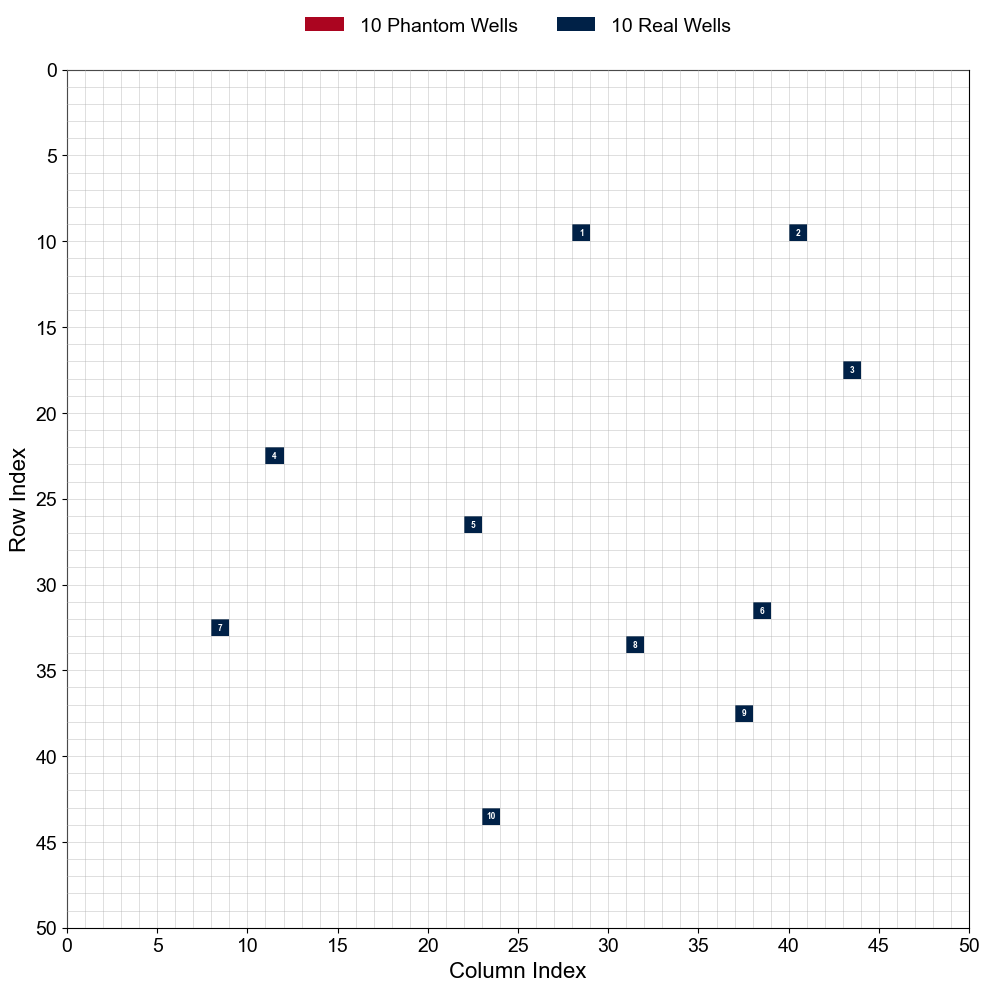

In [15]:
########################
### domain and wells ###
########################

size = 16

# load the real simulation to get grid dimensions
sim_real = flopy.mf6.MFSimulation.load(sim_ws=str(real_ws), verbosity_level=0)
gwf = sim_real.get_model("real")
nrow, ncol = gwf.dis.nrow.get_data(), gwf.dis.ncol.get_data()

# load Phantom simulations to get Phantom locations
phantom_coords = []
for folder in [f for f in os.listdir(sims_dir) if f.startswith("phantom_")]:
    try:
        p_sim = flopy.mf6.MFSimulation.load(sim_ws=str(sims_dir/folder), verbosity_level=0, load_only=['wel'])
        spd_dict = p_sim.get_model().wel.stress_period_data.get_data()
        if 0 in spd_dict:
            for entry in spd_dict[0]:
                phantom_coords.append(entry['cellid'][1:])
    except: continue

perimeter_mask = np.zeros((nrow, ncol))
for r, c in set(phantom_coords):
    perimeter_mask[r, c] = 1

# get Real well locations
real_spd = gwf.wel.stress_period_data.get_data()[0]
real_mask = np.zeros((nrow, ncol))
for e in real_spd:
    r, c = e['cellid'][1], e['cellid'][2]
    real_mask[r, c] = 1

# plot
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.set_facecolor('white')

# base map (empty, just to set extent and aspect)
mapview = flopy.plot.PlotMapView(model=gwf, ax=ax, extent=(0, ncol, 0, nrow))

# Phantom wells
sorted_phantoms = sorted(list(set(phantom_coords)))

for i, (r, c) in enumerate(sorted_phantoms):
    # visual centre of the cell
    x_pos = c + 0.5
    y_pos = nrow - r - 0.5
    
    rect = patches.Rectangle((c, nrow - r - 1), 1, 1, 
                             linewidth=0, facecolor='#AB0520', zorder=2)
    ax.add_patch(rect)
    
    # sequential number label
    ax.text(x_pos, y_pos, str(i + 1), 
            color='white', fontsize=size-10, fontweight='bold',
            ha='center', va='center', zorder=4)

# Real wells
real_spd = gwf.wel.stress_period_data.get_data()[0]
for entry in real_spd:
    _, r_w, c_w = entry['cellid']
    rect = patches.Rectangle((c_w, nrow - r_w - 1), 1, 1, linewidth=0, facecolor='#002147', zorder=3)
    ax.add_patch(rect)

# grid lines
grid_cfg = {'color': "#B3B3B3", 'lw': 0.5, 'alpha': 0.6, 'zorder': 100} # Keep zorder high
for x in range(ncol + 1):
    ax.plot([x, x], [0, nrow], **grid_cfg)
for y in range(nrow + 1):
    ax.plot([0, ncol], [y, y], **grid_cfg)

# labels
ax.set_xlabel("Column Index", fontsize=size)
ax.set_ylabel("Row Index", fontsize=size)

# ticks
ax.set_xticks(np.arange(0, ncol + 1, 5))
ax.set_yticks(np.arange(0, nrow + 1, 5))

# reverse y-axis tick labels to match row indexing
ax.set_yticklabels(np.arange(0, nrow + 1, 5)[::-1]) 

# tick parameters
ax.tick_params(axis='both', which='major', labelsize=size-2)

ax.set_xlim(0, ncol)
ax.set_ylim(0, nrow)

# legend
legend_elements = [
    patches.Patch(facecolor='#AB0520', edgecolor='none', label=f'{len(phantom_coords)} Phantom Wells'),
    patches.Patch(facecolor='#002147', edgecolor='none', label=f'{len(real_spd)} Real Wells')
]

ax.legend(
    handles=legend_elements, 
    loc='lower center', 
    bbox_to_anchor=(0.5, 1.02),
    ncol=2,               
    facecolor='white', 
    edgecolor='none',   
    framealpha=1, 
    fontsize=size-2
)

plt.tight_layout()
plt.savefig(f"{root}_incdd_domain.svg", dpi=300, bbox_inches='tight')
plt.show()

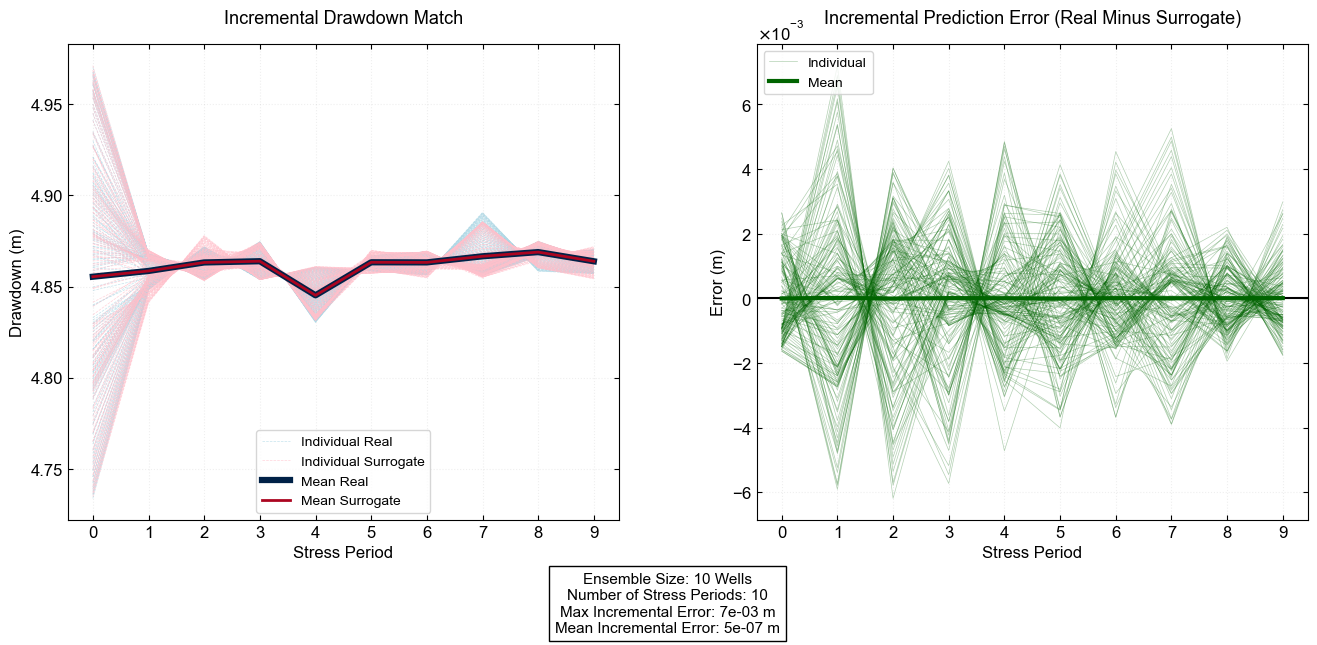

In [18]:
###############
### results ###
###############

# define paths to results
results_path = Path.cwd().parent / "results"

# real_cum: drawdown from the Real simulation 
real_cum = pd.read_csv(results_path / f"{root}_target_drawdown.csv", index_col=0)

# surrogate_cum: drawdown from the Surrogate simulation with the best fit to the Real
surrogate_cum = pd.read_csv(results_path / f"{root}_surrogate_match.csv", index_col=0)

# calculate incremental drawdown and error
real_inc = real_cum.diff().fillna(real_cum.iloc[0])
surrogate_inc = surrogate_cum.diff().fillna(surrogate_cum.iloc[0])
error_inc_df = real_inc - surrogate_inc

# calculate means for plotting
real_inc_mean = real_inc.mean(axis=1)
surrogate_inc_mean = surrogate_inc.mean(axis=1)
error_inc_mean = error_inc_df.mean(axis=1)

# set up plot
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
plt.subplots_adjust(wspace=0.25, bottom=0.2)

# helper function to format axes consistently
def format_axes(ax):
    ax.tick_params(axis='both', which='both', direction='in', 
                   top=True, right=True, labelsize=12)
    # Force integer ticks for Stress Periods
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.grid(True, alpha=0.2, linestyle=':')

# plot 1: incremental drawdown match

for i, col in enumerate(real_inc.columns):
    # individual Real fits
    t_label = 'Individual Real' if i == 0 else ""
    ax1.plot(real_inc.index, real_inc[col], color='lightblue', alpha=0.7, lw=0.5, label=t_label, linestyle='--', zorder=1)
    
    # individual Surrogate fits
    s_label = 'Individual Surrogate' if i == 0 else ""
    ax1.plot(surrogate_inc.index, surrogate_inc[col], color='pink', alpha=0.7, lw=0.5, label=s_label, linestyle='--', zorder=2)

ax1.plot(real_inc_mean.index, real_inc_mean, color='#002147', lw=4.5, 
         label='Mean Real', zorder=5)
ax1.plot(surrogate_inc_mean.index, surrogate_inc_mean, color='#AB0520', lw=2, 
         label='Mean Surrogate', zorder=6)

ax1.set_title("Incremental Drawdown Match", fontsize=13, pad=15)
ax1.set_ylabel("Drawdown (m)", fontsize=12)
ax1.set_xlabel("Stress Period", fontsize=12)
ax1.legend(loc='lower center', frameon=True, fontsize=10)
format_axes(ax1)

# plot 2: incremental error

for i, col in enumerate(error_inc_df.columns):
    label = 'Individual' if i == 0 else ""
    ax2.plot(error_inc_df.index, error_inc_df[col], color='darkgreen', alpha=0.3, lw=0.5, label=label, zorder=1)

ax2.plot(error_inc_mean.index, error_inc_mean, color='darkgreen', lw=3, label='Mean', zorder=5)
ax2.axhline(0, color='black', lw=1.5, zorder=2)

# scientific notation for y-axis to handle small errors without leading zeros
ax2.yaxis.set_major_formatter(mticker.ScalarFormatter(useMathText=True))
ax2.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
ax2.yaxis.get_offset_text().set_fontsize(12)

ax2.set_title("Incremental Prediction Error (Real Minus Surrogate)", fontsize=13, pad=15)
ax2.set_ylabel("Error (m)", fontsize=12)
ax2.set_xlabel("Stress Period", fontsize=12)
ax2.legend(loc='upper left', fontsize=10)
format_axes(ax2)

# summary stats textbox
stats_text = (f"Ensemble Size: {len(phantom_coords)} Wells\n"
              f"Number of Stress Periods: {len(real_cum)}\n"
              f"Max Incremental Error: {error_inc_df.abs().max().max():.0e} m\n"
              f"Mean Incremental Error: {error_inc_df.mean().mean():.0e} m")

fig.text(0.5, 0.04, stats_text, ha='center', fontsize=11, 
         bbox=dict(facecolor='white', alpha=1, edgecolor='black', boxstyle='square,pad=0.4'))

plt.savefig(f"{root}_incdd_results.svg", dpi=300, bbox_inches='tight')
plt.show()


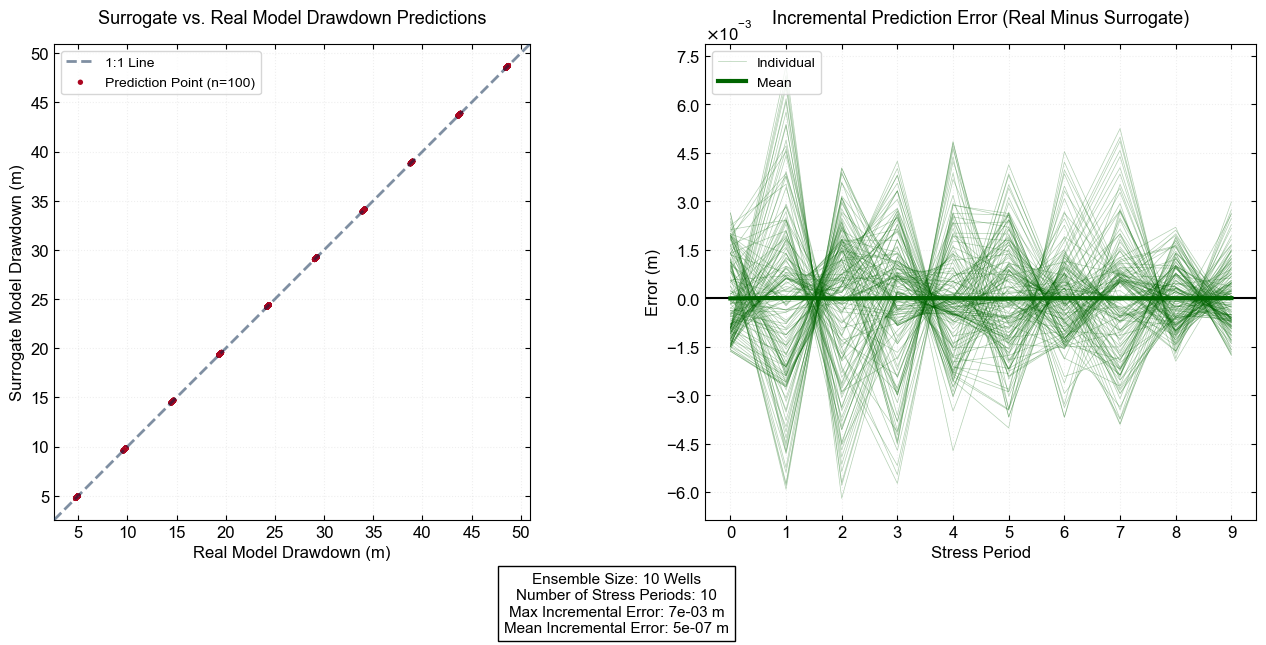

1560

In [21]:
###############
### results ###
###############

# define paths to results
from numpy.ma import count


results_path = Path.cwd().parent / "results"

# real_cum: drawdown from the Real simulation 
real_cum = pd.read_csv(results_path / f"{root}_target_drawdown.csv", index_col=0)

# surrogate_cum: drawdown from the Surrogate simulation with the best fit to the Real
surrogate_cum = pd.read_csv(results_path / f"{root}_surrogate_match.csv", index_col=0)

# calculate incremental drawdown and error
real_inc = real_cum.diff().fillna(real_cum.iloc[0])
surrogate_inc = surrogate_cum.diff().fillna(surrogate_cum.iloc[0])
error_inc_df = real_inc - surrogate_inc

# calculate means for plotting
real_inc_mean = real_inc.mean(axis=1)
surrogate_inc_mean = surrogate_inc.mean(axis=1)
error_inc_mean = error_inc_df.mean(axis=1)

# set up plot
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
plt.subplots_adjust(wspace=0.25, bottom=0.2)

# helper function to format axes consistently
def format_axes(ax):
    ax.tick_params(axis='both', which='both', direction='in', 
                   top=True, right=True, labelsize=12)
    # Force integer ticks for Stress Periods
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.grid(True, alpha=0.2, linestyle=':')

# plot 1: Phantom vs. Real drawdown scatter plot, at every point and stress period

vals_all = np.concatenate([real_cum.values.flatten(), surrogate_cum.values.flatten()])
vmin, vmax = vals_all.min(), vals_all.max()
buffer = (vmax - vmin) * 0.05
common_lims = (vmin - buffer, vmax + buffer)

# common limits for x and y axes
ax1.set_xlim(common_lims)
ax1.set_ylim(common_lims)

# 1:1 line
ax1.plot(common_lims, common_lims, color='#002147', alpha=0.5, linestyle='--', lw=2, label='1:1 Line', zorder=3)
ax1.scatter(real_cum, surrogate_cum, color='#AB0520', s=15, edgecolors='none', label=f'Prediction Point (n={(len(real_cum)*len(phantom_coords))})', zorder=1)

# square aspect ratio
ax1.set_aspect('equal', adjustable='box')

ax1.set_title("Surrogate vs. Real Model Drawdown Predictions", fontsize=13, pad=15)
ax1.set_ylabel("Surrogate Model Drawdown (m)", fontsize=12)
ax1.set_xlabel("Real Model Drawdown (m)", fontsize=12)
ax1.legend(loc='upper left', fontsize=10)

# plot 2: incremental error

for i, col in enumerate(error_inc_df.columns):
    label = 'Individual' if i == 0 else ""
    ax2.plot(error_inc_df.index, error_inc_df[col], color='darkgreen', alpha=0.3, lw=0.5, label=label, zorder=1)

ax2.plot(error_inc_mean.index, error_inc_mean, color='darkgreen', lw=3, label='Mean', zorder=5)
ax2.axhline(0, color='black', lw=1.5, zorder=2)

# scientific notation for y-axis to handle small errors without leading zeros
ax2.yaxis.set_major_formatter(mticker.ScalarFormatter(useMathText=True))
ax2.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
ax2.yaxis.get_offset_text().set_fontsize(12)

ax2.set_title("Incremental Prediction Error (Real Minus Surrogate)", fontsize=13, pad=15)
ax2.set_ylabel("Error (m)", fontsize=12)
ax2.set_xlabel("Stress Period", fontsize=12)
ax2.legend(loc='upper left', fontsize=10)

# format axes per function
format_axes(ax1)
format_axes(ax2)

# summary stats textbox
stats_text = (f"Ensemble Size: {len(phantom_coords)} Wells\n"
              f"Number of Stress Periods: {len(real_cum)}\n"
              f"Max Incremental Error: {error_inc_df.abs().max().max():.0e} m\n"
              f"Mean Incremental Error: {error_inc_df.mean().mean():.0e} m")

fig.text(0.5, 0.04, stats_text, ha='center', fontsize=11, 
         bbox=dict(facecolor='white', alpha=1, edgecolor='black', boxstyle='square,pad=0.4'))

plt.savefig(f"{root}_incdd_results.svg", dpi=300, bbox_inches='tight')
plt.show()

count(real_cum)
